In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

#R squared 
from sklearn.metrics import r2_score as R2

from sklearn.metrics import mean_absolute_error as mae 
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import root_mean_squared_error as rmse

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

#features engineering
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import MinMaxScaler

from sklearn.datasets import make_regression
from sklearn.model_selection import KFold, cross_validate

#Grid search CV
from sklearn.model_selection import GridSearchCV

sns.set_theme() 

In [2]:
#concrete compressive strength dataset fro kaggle
file_name = "ccs.csv"

data = pd.read_csv(file_name)

df = pd.DataFrame(data)

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


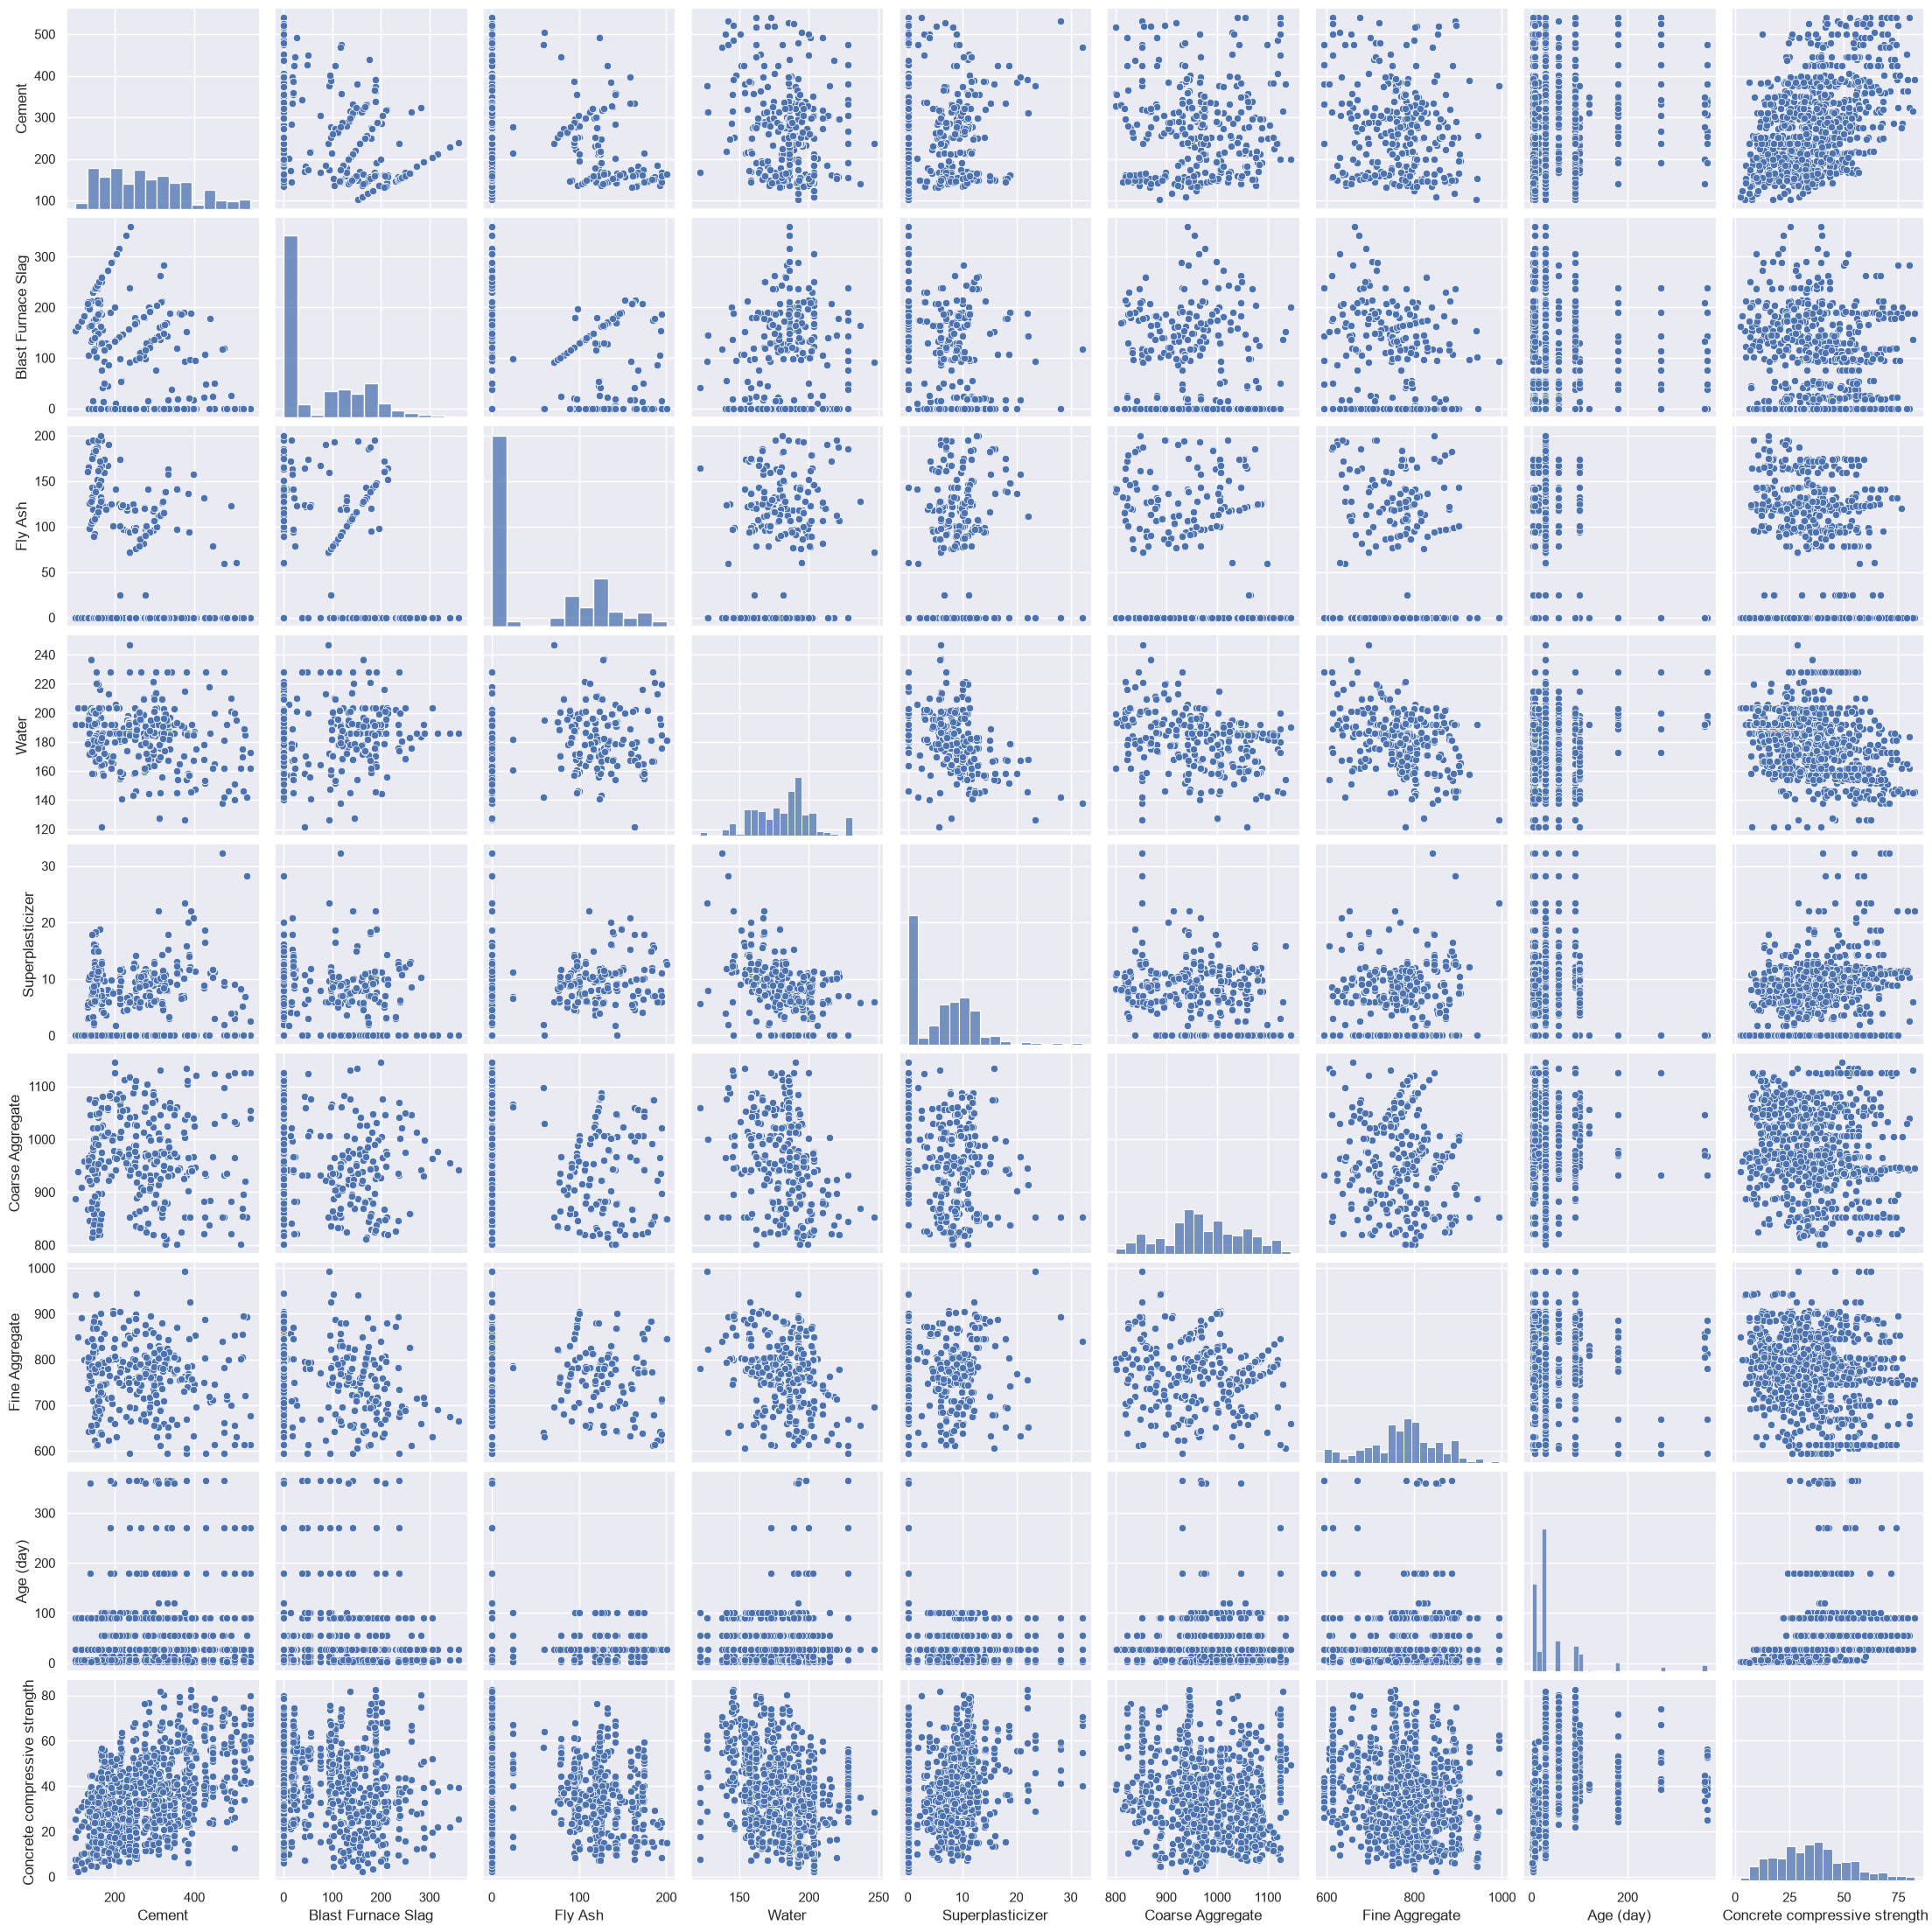

In [4]:
sns.pairplot(df)
plt.show()

<Axes: >

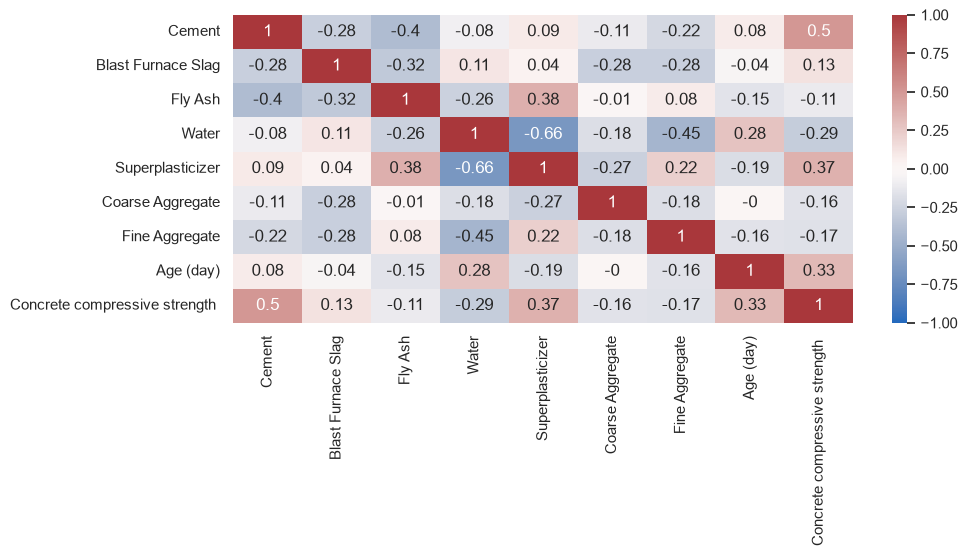

In [5]:
#correlation matrix
correlation = df.corr().round(2)

plt.figure(figsize=(10, 4))

#cmpa [vlag, seismic, coolwarm, viridis, mako, crest
sns.heatmap(correlation, annot=True, cmap="vlag", vmin=-1, vmax=1)

In [6]:
#replace outliers (Data cleaning)
df.replace('?', -9999, inplace=True)

#split dataset
X = df.iloc[:, 0: -1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#SVR model 
model = SVR()

model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [7]:
#evaluating training and testing data

y_model_train = model.predict(X_train)
y_model_test = model.predict(X_test)

print(R2(y_train, y_model_train))
print(R2(y_test, y_model_test))

0.25465177867462463
0.2320261036478357


In [8]:
#transform y(output) into a 2d array
y = y.reshape(len(y), 1)

In [9]:
#transforming dataset (features engineering)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_transformed = scaler_x.fit_transform(X)
y_transformed = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_transformed, y_transformed, test_size=0.2, random_state=42)

#SVR model 
model = SVR()

model.fit(X_train, y_train)

C:\Users\user\Documents\Python Code\ML\Practice1\slmlenv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [10]:
#evaluating training and testing data after features scaling

y_model_train = model.predict(X_train)
y_model_test = model.predict(X_test)

print(R2(y_train, y_model_train))
print(R2(y_test, y_model_test))

0.8660250087380568
0.8037453209789065


In [12]:
#actual prediction vs the model prediction example
print(scaler_y.inverse_transform(y_train[1].reshape(-1,1)), scaler_y.inverse_transform(y_model_train[1].reshape(-1,1)))

[[62.05284]] [[54.03678893]]


In [21]:
#prediction of new data

#Cement	Blast Furnace Slag	Fly Ash	Water	Superplasticizer	Coarse Aggregate	Fine Aggregate	Age (day)	Concrete compressive strength
X_new = [[540.0,	100.0,	200.0,	162.0,	22.5,	1040.0,	676.0,	90]]

X_new_scaled = scaler_x.transform(X_new)
prediction = model.predict(X_new_scaled)

# print(prediction)
scaler_y.inverse_transform(prediction.reshape(-1,1))

array([[55.36112979]])

In [14]:
### K-fold cross-validation analysis

# 2. Define the K-Fold strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. List the built-in scoring metrics
# Note: Sklearn metrics follow a "higher is better" rule, so error losses are negative
scoring_metrics = {
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
}

# 4. Perform cross-validation
cv_results = cross_validate(
    model, X_transformed, y_transformed, cv=kf, scoring=scoring_metrics, n_jobs=-1
)

# 5. Extract, clean, and print the results
print(f"--- 5-Fold Cross-Validation Scores ---")

# MAE (Convert back to positive values)
mae_scores = -cv_results["test_mae"]
print(f"MAE:  {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")

# R2 (Already naturally oriented)
r2_scores = cv_results["test_r2"]
print(f"R2:   {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")

# RMSE (Convert back to positive values)
rmse_scores = -cv_results["test_rmse"]
print(f"RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")


--- 5-Fold Cross-Validation Scores ---
MAE:  0.0702 (+/- 0.0043)
R2:   0.8136 (+/- 0.0157)
RMSE: 0.0895 (+/- 0.0052)


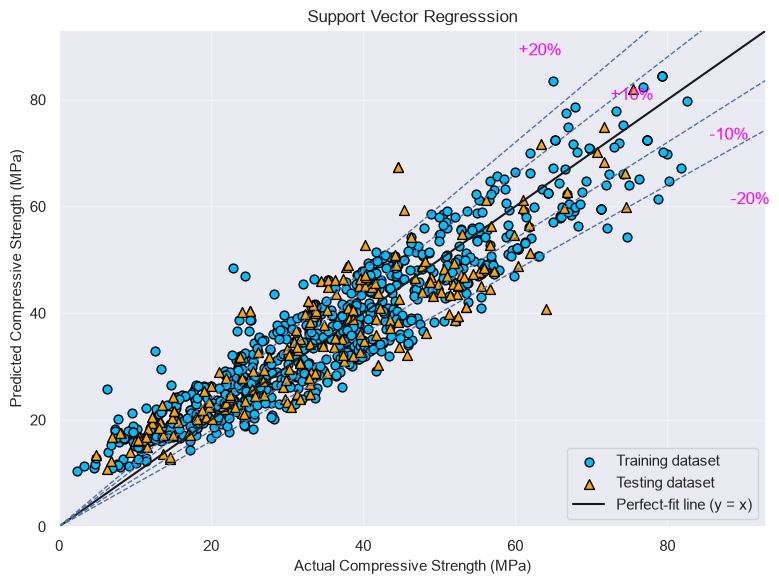

In [15]:
# model visualization

# Actual values
y_actual_train = scaler_y.inverse_transform(y_train)
y_actual_test = scaler_y.inverse_transform(y_test)

# Predicted values (reshaped)
y_pred_train =scaler_y.inverse_transform(y_model_train.reshape(-1,1))
y_pred_test = scaler_y.inverse_transform(y_model_test.reshape(-1,1))

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(y_actual_train, y_pred_train,
            color='deepskyblue',
            edgecolor='black',
            s=40,
            label='Training dataset')

plt.scatter(y_actual_test, y_pred_test,
            color='orange',
            marker='^',
            edgecolor='black',
            s=50,
            label='Testing dataset')

# Axis limits
max_val = max(
    np.max(y_actual_train),
    np.max(y_actual_test),
    np.max(y_pred_train),
    np.max(y_pred_test)
) * 1.1

x = np.linspace(0, max_val, 100)

# Perfect fit line (y=x)
plt.plot(x, x, 'k-', linewidth=1.5, label='Perfect-fit line (y = x)')

# Error bands
plt.plot(x, 1.10*x, 'b--', linewidth=1)
plt.plot(x, 0.90*x, 'b--', linewidth=1)

plt.plot(x, 1.20*x, 'b--', linewidth=1)
plt.plot(x, 0.80*x, 'b--', linewidth=1)

# Labels for error bands
plt.text(max_val*0.78, max_val*0.86, '+10%', color='magenta')
plt.text(max_val*0.92, max_val*0.78, '-10%', color='magenta')

plt.text(max_val*0.65, max_val*0.95, '+20%', color='magenta')
plt.text(max_val*0.95, max_val*0.65, '-20%', color='magenta')

# Formatting
plt.xlabel('Actual Compressive Strength (MPa)', fontsize=11)
plt.ylabel('Predicted Compressive Strength (MPa)', fontsize=11)

plt.title('Support Vector Regresssion', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.4)
plt.legend(loc='lower right')

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.tight_layout()
plt.show()

In [35]:
# Applying K-fold cross-validation and hyperparameter-tuning using GridSearchCV

#k-fold cross validation/ hyperparameter tunning
clf = GridSearchCV(model, {
    'kernel': ['rbf'],
    'C': [20, 30], # controls the penealty for prediction errors higher value the better
    'gamma': [ 0.7, 0.9], # defines how far the influence of a single training point reaches
    'epsilon':[ 0.008, 0.01] # defines a dead zone where errors are completely ignored
}, cv=5, return_train_score=False)


# Fit the model using ONLY the training data
clf.fit(X_train, y_train)

#print results
# clf.cv_results_

#convert to df table format
clf_df = pd.DataFrame(clf.cv_results_)


#required columns
new_clf_df = clf_df[['rank_test_score', 'params', 'mean_test_score']]

new_clf_df

C:\Users\user\Documents\Python Code\ML\Practice1\slmlenv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\user\Documents\Python Code\ML\Practice1\slmlenv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\user\Documents\Python Code\ML\Practice1\slmlenv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\user\Documents\Python Code\ML\Practice1\slmlenv\Lib\site-packages\sklearn\utils\validation.py:136

,rank_test_score,params,mean_test_score
0,2,"{'C': 20, 'epsilon': 0.008, 'gamma': 0.7, 'ker...",0.859736
1,6,"{'C': 20, 'epsilon': 0.008, 'gamma': 0.9, 'ker...",0.853685
2,1,"{'C': 20, 'epsilon': 0.01, 'gamma': 0.7, 'kern...",0.860383
3,5,"{'C': 20, 'epsilon': 0.01, 'gamma': 0.9, 'kern...",0.855205
4,4,"{'C': 30, 'epsilon': 0.008, 'gamma': 0.7, 'ker...",0.857213
5,8,"{'C': 30, 'epsilon': 0.008, 'gamma': 0.9, 'ker...",0.847508
6,3,"{'C': 30, 'epsilon': 0.01, 'gamma': 0.7, 'kern...",0.857378
7,7,"{'C': 30, 'epsilon': 0.01, 'gamma': 0.9, 'kern...",0.849467


In [36]:
clf.best_params_

{'C': 20, 'epsilon': 0.01, 'gamma': 0.7, 'kernel': 'rbf'}

In [37]:
# Tunned SVR model 
tunned_model = SVR()

tunned_model.set_params(**clf.best_params_)

tunned_model.fit(X_train, y_train)

C:\Users\user\Documents\Python Code\ML\Practice1\slmlenv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.7
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",20
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [38]:
#evaluating training and testing data after 

y_model_train = tunned_model.predict(X_train)
y_model_test = tunned_model.predict(X_test)

print(R2(y_train, y_model_train))
print(R2(y_test, y_model_test))

0.9161443364044792
0.8434778552304804


In [41]:
#actual prediction vs the model prediction example
print(scaler_y.inverse_transform(y_train[3].reshape(-1,1)), scaler_y.inverse_transform(y_model_train[3].reshape(-1,1)))

[[33.39821744]] [[35.97047973]]


In [45]:
#prediction of new data

#Cement	Blast Furnace Slag	Fly Ash	Water	Superplasticizer	Coarse Aggregate	Fine Aggregate	Age (day)	Concrete compressive strength
X_new = [[540.0,	0.0,	0.0,	162.0,	22.5,	1040.0,	676.0,	14]]

X_new_scaled = scaler_x.transform(X_new)
prediction = tunned_model.predict(X_new_scaled)

# print(prediction)
scaler_y.inverse_transform(prediction.reshape(-1,1))

array([[45.07725094]])

In [54]:
#dataframe of the first 5 actual CS vs predicted CS

values_df = pd.DataFrame()

values_df[["Actual Values"]] = scaler_y.inverse_transform(y_train);
values_df[["Predicted Values"]] = scaler_y.inverse_transform(y_model_train.reshape(-1,1));

values_df.head()

,Actual Values,Predicted Values
0,27.681082,27.669617
1,62.052840,52.184188
2,23.800712,26.262272
3,33.398217,35.970480
4,7.398077,15.574165
